# Hochschule für Musik, Theater und Medien Hannover - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS fak_name,
                        'Hochschule für Musik, Theater und Medien Hannover' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202603` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202603` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/00x67m532' -- 'Hochschule für Musik, Theater und Medien Hannover'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,"Hochschule für Musik, Theater und Medien Hannover","Hochschule für Musik, Theater und Medien Hanno...",https://openalex.org/W4285186288
1,not assigned,"Hochschule für Musik, Theater und Medien Hannover","Hanover University of Music, Drama and Media, ...",https://openalex.org/W4280508055
2,not assigned,"Hochschule für Musik, Theater und Medien Hannover","Hanover University of Music, Drama and Media, ...",https://openalex.org/W4280508055
3,not assigned,"Hochschule für Musik, Theater und Medien Hannover",Institute of Music Physiology and Musician's M...,https://openalex.org/W4312211800
4,not assigned,"Hochschule für Musik, Theater und Medien Hannover",Institute of Music Physiology and Musician's M...,https://openalex.org/W4312211800


In [16]:
MAPPING_DICT = {
    #'Europäisches Zentrum für Jüdische Musik (EZJM)': [],
    #'Fachbereich Musiktheorie': [],
    #'Forschungszentrum Musik und Gender': [],
    #'Institut für Alte Musik': [],
    'Institut für Journalistik und Kommunikationsforschung': ['journalism', 'journalistik', 'kommunikationsforschung',
                                                              'communication (research|science)'
                                                             ],
    #'Institut für Kammermusik': [],
    'Institut für Musikphysiologie und Musikermedizin': ['physiology', 'musikphysiologie'],
    'Institut für Musikpädagogische Forschung': ['music education research'],
    #'Institut für Neue Musik': [],
    'Institut zur Früh-Förderung musikalisch Hochbegabter': ['music lab'],
    'Musikwissenschaftliches Institut': ['musicology', 'musikwissenschaftliches'],
    #'Popinstitut Hannover': [],
    #'Studienzentrum Weltmusik': []
}

In [17]:
with open('./mapping_tables_fak/hmtmh.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [18]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [19]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned', 'fak_name'] = \
           df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [20]:
df_with_inst

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,Institut für Journalistik und Kommunikationsfo...,"Hochschule für Musik, Theater und Medien Hannover","Hochschule für Musik, Theater und Medien Hanno...",https://openalex.org/W4285186288
1,None,"Hochschule für Musik, Theater und Medien Hannover","Hanover University of Music, Drama and Media, ...",https://openalex.org/W4280508055
2,None,"Hochschule für Musik, Theater und Medien Hannover","Hanover University of Music, Drama and Media, ...",https://openalex.org/W4280508055
3,Institut für Musikphysiologie und Musikermedizin,"Hochschule für Musik, Theater und Medien Hannover",Institute of Music Physiology and Musician's M...,https://openalex.org/W4312211800
4,Institut für Musikphysiologie und Musikermedizin,"Hochschule für Musik, Theater und Medien Hannover",Institute of Music Physiology and Musician's M...,https://openalex.org/W4312211800
...,...,...,...,...
349,Institut für Journalistik und Kommunikationsfo...,"Hochschule für Musik, Theater und Medien Hannover",Institut für Journalistik und Kommunikationsfo...,https://openalex.org/W4386438410
350,Institut für Journalistik und Kommunikationsfo...,"Hochschule für Musik, Theater und Medien Hannover",Dept. of Journalism and Communication Research...,https://openalex.org/W3046212981
351,Institut für Journalistik und Kommunikationsfo...,"Hochschule für Musik, Theater und Medien Hannover",Dept. of Journalism and Communication Research...,https://openalex.org/W3046212981
352,Institut für Journalistik und Kommunikationsfo...,"Hochschule für Musik, Theater und Medien Hannover",Department of Journalism and Communication Res...,https://openalex.org/W3036794409


In [21]:
df_with_inst[df_with_inst.fak_name.isnull()].raw_affiliation_string.unique()

array(['Hanover University of Music, Drama and Media, Neues Haus 1, 30175, Hannover, Germany',
       'Hanover University of Music, Drama and Media, Neues Haus 1, 30175, Hannover, Germany. reinhard.kopiez@hmtm-hannover.de',
       'Hochschule für Musik, Theater und Medien Hannover',
       'Hanover University of Music, Drama and Media',
       'Hanover University of Music, Drama and Media, Hanover, Germany',
       'Hanover University of Music, Drama, and Media',
       'Hochschule für Musik, Theater und Medien Hannover. 115',
       'Hanover University of Music, Drama and Media, Germany',
       'Hanover University of Music, Drama, and Media, Germany',
       'Hanover University of Music, Drama and Media , Hannover, Niedersachsen,',
       'Hannover University of Music, Drama and Media',
       'University of Music Theater and Media  Hannover Germany',
       'Hochschule für Musik, Theater und Medien, Hanover, Germany',
       'Europäisches Zentrum für Jüdische Musik , 38989 Hochschul

In [22]:
df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()

,fak_name,openalex_id
0,Institut für Journalistik und Kommunikationsfo...,107
1,Institut für Musikphysiologie und Musikermedizin,118
2,Institut für Musikpädagogische Forschung,4
3,Institut zur Früh-Förderung musikalisch Hochbe...,14
4,Musikwissenschaftliches Institut,5
5,NaN,106


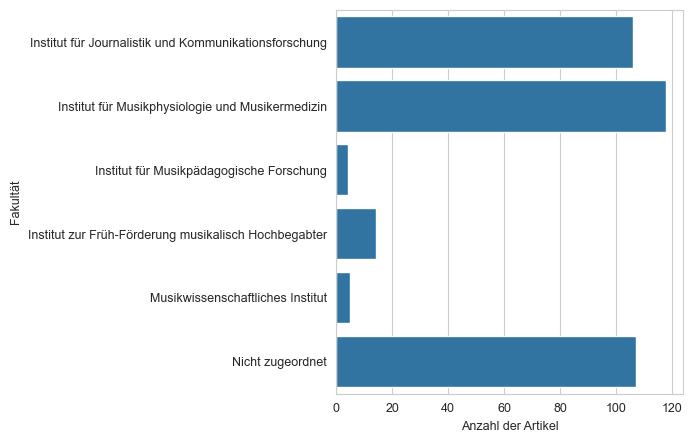

In [13]:
df_plot = df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='fak_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [14]:
df_plot[df_plot.fak_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.6977401129943502

In [15]:
MAPPING_DICT_DEPT = {}
MAPPING_DICT_INST = {}

In [23]:
gerit_ids = pd.read_csv('../../data/gerit_inst_with_ids.csv')
gerit_ids = gerit_ids[gerit_ids.parent_name == 'Hochschule für Musik, Theater und Medien Hannover'][['inst_name', 'dfg_id']].to_dict(orient='records')

def search_gerit_id(name: str):  
    for gerit_id in gerit_ids:
        if gerit_id['inst_name'] == name:
            return gerit_id.get('dfg_id')

leibniz_dicts = dict()

for faculty, faculty_patterns in MAPPING_DICT.items():

    faculty_dict = dict()

    faculty_dict['faculty_id'] = search_gerit_id(faculty)
    faculty_dict['faculty_patterns'] = faculty_patterns

    faculty_suborganisations = dict()
    
    if MAPPING_DICT_DEPT.get(faculty):
        for department, department_patterns in MAPPING_DICT_DEPT.get(faculty).items():

            department_dict = dict()
            
            department_dict['department_id'] = search_gerit_id(department)
            department_dict['department_patterns'] = department_patterns

            department_suborganisations = dict()
            
            if MAPPING_DICT_INST.get(department):
                for institute, institute_patterns in MAPPING_DICT_INST.get(department).items():

                    institute_dict = dict()
            
                    institute_dict['institute_id'] = search_gerit_id(institute)
                    institute_dict['institute_patterns'] = institute_patterns

                    department_suborganisations[institute] = institute_dict
                    
            department_dict['suborganisations'] = department_suborganisations

            faculty_suborganisations[department] = department_dict

    faculty_dict['suborganisations'] = faculty_suborganisations

    leibniz_dicts[faculty] = faculty_dict

with open('../../data/mappings/hmtmh.json', mode='w', encoding='utf-8') as f:
    json.dump(leibniz_dicts, f, ensure_ascii=False)